In [2]:
!pip install --upgrade numpy



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!python -c "import numpy; print(numpy.__version__)"


2.2.6


In [3]:
# =============================================================================
# CELL 1: IMPORTS AND SEED SETTING
# =============================================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import math
import random

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("✅ Libraries imported | Device:", device)


✅ Libraries imported | Device: cpu


In [4]:
# =============================================================================
# CELL 2: DATA LOADING
# =============================================================================

csv_path = r"C:\Users\chari\Downloads\Major Project\reduced_data_4.csv\reduced_data_4.csv"
df = pd.read_csv(csv_path)

print(df.info())
print("\nShape:", df.shape)
print("\nMissing values:\n", df.isnull().sum().head())
print("\n✅ BoT-IoT dataset loaded")


C:\Users\chari\AppData\Local\Temp\ipykernel_24564\1960417235.py:6: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668522 entries, 0 to 668521
Data columns (total 46 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   pkSeqID                           668522 non-null  int64  
 1   stime                             668522 non-null  float64
 2   flgs                              668522 non-null  object 
 3   flgs_number                       668522 non-null  int64  
 4   proto                             668522 non-null  object 
 5   proto_number                      668522 non-null  int64  
 6   saddr                             668522 non-null  object 
 7   sport                             668522 non-null  object 
 8   daddr                             668522 non-null  object 
 9   dport                             668522 non-null  object 
 10  pkts                              668522 non-null  int64  
 11  bytes                             668522 non-null  i

category
DDoS              576884
Reconnaissance     91082
Normal               477
Theft                 79
Name: count, dtype: int64


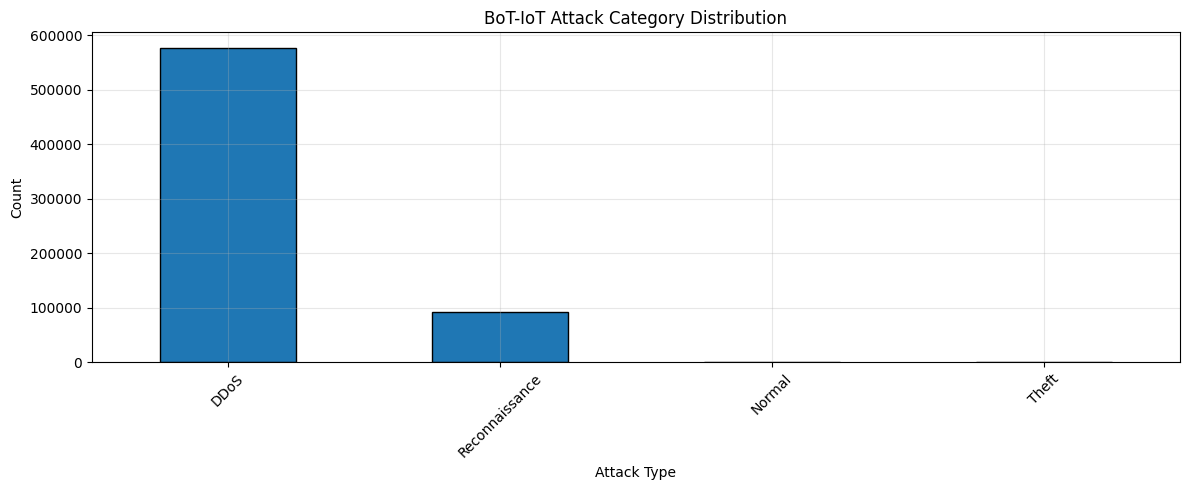

In [5]:
# =============================================================================
# CELL 3: TARGET DISTRIBUTION
# =============================================================================

attack_dist = df['category'].value_counts()
print(attack_dist)

plt.figure(figsize=(12,5))
attack_dist.plot(kind='bar', edgecolor='black')
plt.title("BoT-IoT Attack Category Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


category
DDoS              576884
Reconnaissance     91082
Normal               477
Theft                 79
Name: count, dtype: int64


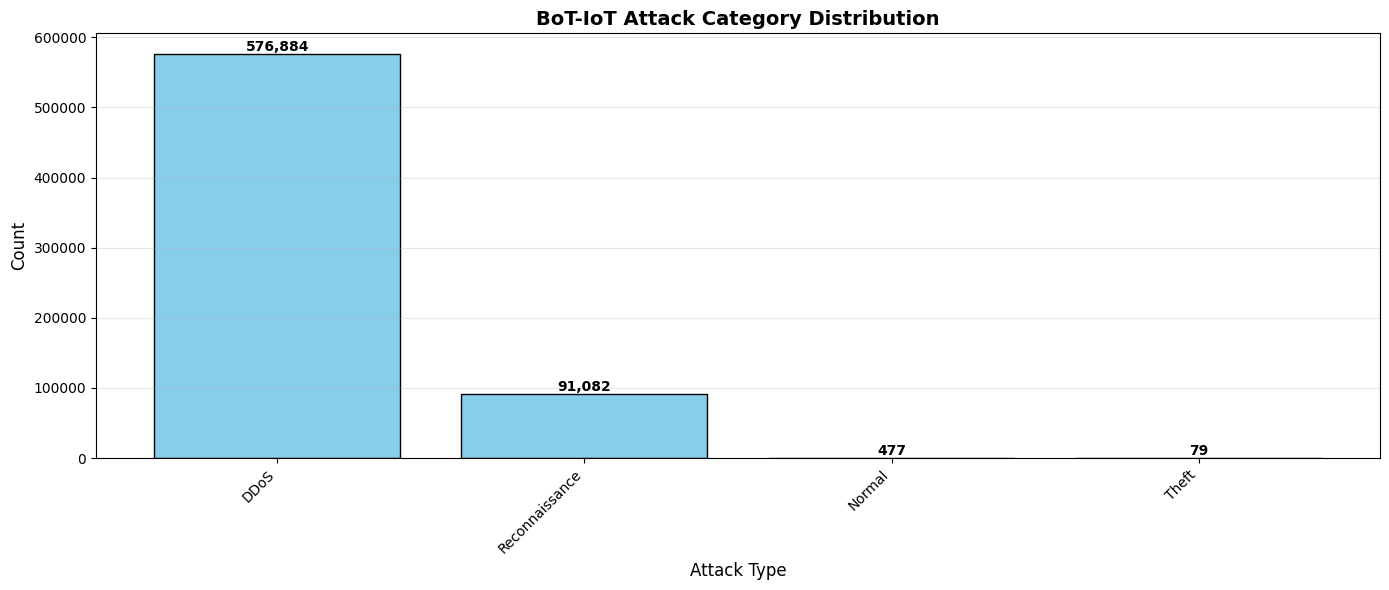

In [6]:
# =============================================================================
# CELL 3: TARGET DISTRIBUTION (WITH COUNT ANNOTATIONS)
# =============================================================================

attack_dist = df['category'].value_counts()
print(attack_dist)

plt.figure(figsize=(14, 6))

bars = plt.bar(
    attack_dist.index,
    attack_dist.values,
    color='skyblue',
    edgecolor='black'
)

plt.title("BoT-IoT Attack Category Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Attack Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# 🔹 Add count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


In [7]:
# =============================================================================
# CELL 4: FEATURE CLEANING
# =============================================================================

drop_cols = [
    'pkSeqID', 'stime', 'ltime',
    'saddr', 'daddr',
    'subcategory',
    'label'   # keep only category for multi-class
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

print("Remaining columns:", df.columns.tolist())
print("✅ Feature cleaning done")


Remaining columns: ['flgs', 'flgs_number', 'proto', 'proto_number', 'sport', 'dport', 'pkts', 'bytes', 'state', 'state_number', 'seq', 'dur', 'mean', 'stddev', 'sum', 'min', 'max', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate', 'TnBPSrcIP', 'TnBPDstIP', 'TnP_PSrcIP', 'TnP_PDstIP', 'TnP_PerProto', 'TnP_Per_Dport', 'AR_P_Proto_P_SrcIP', 'AR_P_Proto_P_DstIP', 'N_IN_Conn_P_DstIP', 'N_IN_Conn_P_SrcIP', 'AR_P_Proto_P_Sport', 'AR_P_Proto_P_Dport', 'Pkts_P_State_P_Protocol_P_DestIP', 'Pkts_P_State_P_Protocol_P_SrcIP', 'attack', 'category']
✅ Feature cleaning done


In [8]:
# =============================================================================
# CELL 5: CATEGORICAL ENCODING
# =============================================================================

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('category')

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

print("Encoded categorical columns:", categorical_cols)


Encoded categorical columns: ['flgs', 'proto', 'sport', 'dport', 'state']


In [9]:
# =============================================================================
# CELL 6: TARGET ENCODING
# =============================================================================

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df['category'])
X = df.drop(columns=['category'])

print("Classes:", target_encoder.classes_)
print("X shape:", X.shape)


Classes: ['DDoS' 'Normal' 'Reconnaissance' 'Theft']
X shape: (668522, 39)


In [10]:
# =============================================================================
# CELL 7: FEATURE SCALING
# =============================================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean:", X_scaled.mean(), "Std:", X_scaled.std())


Mean: 4.045721150693712e-17 Std: 0.999999999999997


In [11]:
# =============================================================================
# CELL 8: HIERARCHICAL DATA CREATION
# =============================================================================

def create_hierarchical_data(data, labels, window_size=5):
    X_h, y_h = [], []
    for i in range(len(data) - window_size):
        X_h.append(data[i:i+window_size])
        y_h.append(labels[i+window_size])
    return np.array(X_h, dtype=np.float32), np.array(y_h, dtype=np.int64)

WINDOW_SIZE = 5
X_final, y_final = create_hierarchical_data(X_scaled, y, WINDOW_SIZE)
num_classes = len(np.unique(y_final))

print("Hierarchical shape:", X_final.shape)
print("Classes:", num_classes)


Hierarchical shape: (668517, 5, 39)
Classes: 4


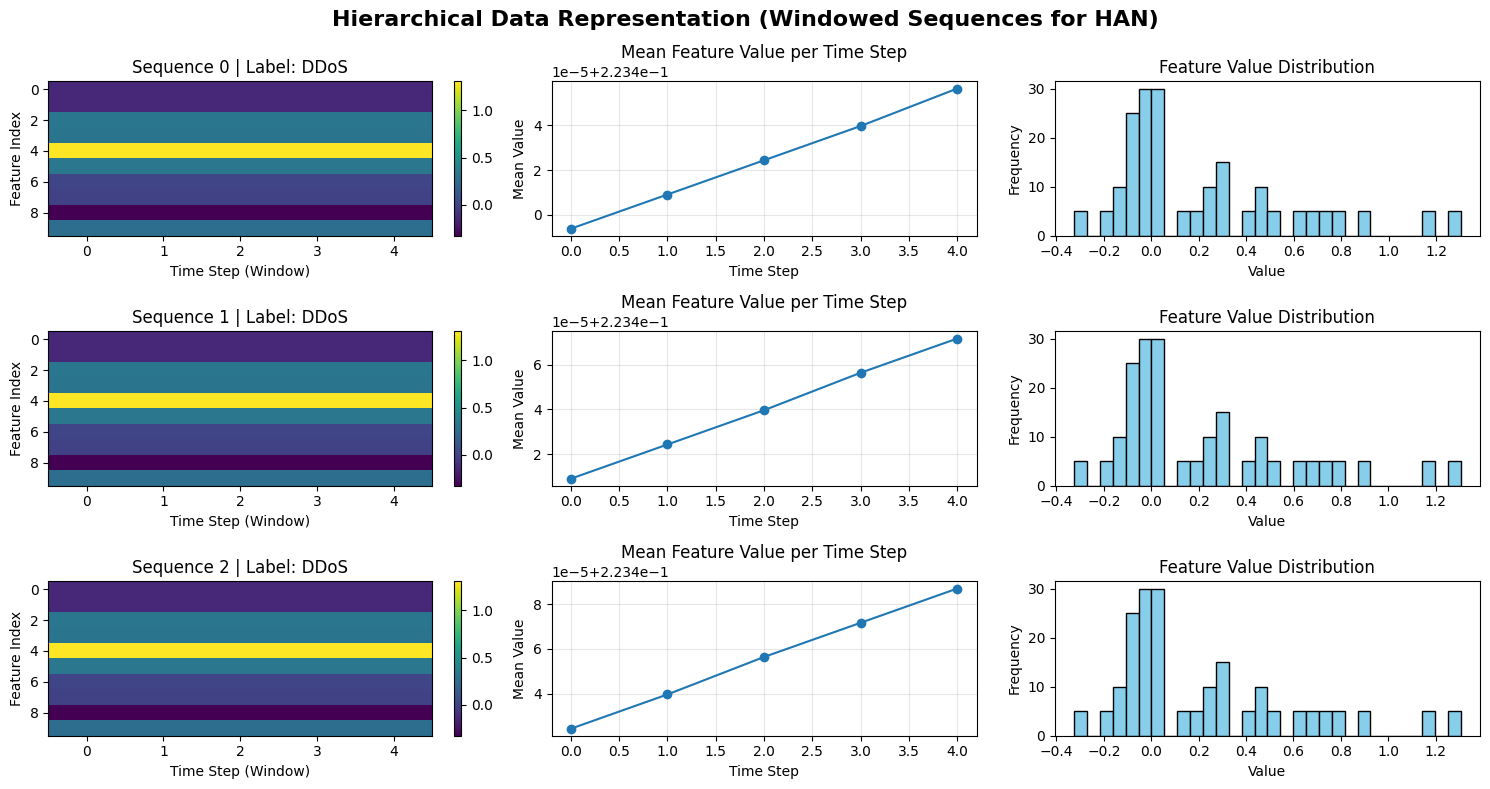

In [21]:
# =============================================================================
# CELL 8A: HIERARCHICAL DATA VISUALIZATION
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

# Number of sequences to visualize
num_samples = 3
num_features_to_show = min(10, X_final.shape[2])  # show first 10 features

plt.figure(figsize=(15, 8))

for i in range(num_samples):
    seq = X_final[i]  # shape: (WINDOW_SIZE, Features)
    label = target_encoder.classes_[y_final[i]]

    # 🔹 Heatmap-like visualization (Time vs Features)
    plt.subplot(num_samples, 3, i*3 + 1)
    plt.imshow(seq[:, :num_features_to_show].T, aspect='auto', cmap='viridis')
    plt.colorbar(fraction=0.046)
    plt.title(f"Sequence {i} | Label: {label}")
    plt.xlabel("Time Step (Window)")
    plt.ylabel("Feature Index")

    # 🔹 Mean feature value over time
    plt.subplot(num_samples, 3, i*3 + 2)
    plt.plot(seq.mean(axis=1), marker='o')
    plt.title("Mean Feature Value per Time Step")
    plt.xlabel("Time Step")
    plt.ylabel("Mean Value")
    plt.grid(alpha=0.3)

    # 🔹 Distribution of values in the sequence
    plt.subplot(num_samples, 3, i*3 + 3)
    plt.hist(seq.flatten(), bins=30, color='skyblue', edgecolor='black')
    plt.title("Feature Value Distribution")
    plt.xlabel("Value")
    plt.ylabel("Frequency")

plt.suptitle(
    "Hierarchical Data Representation (Windowed Sequences for HAN)",
    fontsize=16,
    fontweight='bold'
)
plt.tight_layout()
plt.show()


In [13]:
# =============================================================================
# CELL 9: TRAIN-TEST SPLIT (NUMPY-SAFE)
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final
)

# ✅ SAFE tensor conversion (NO torch.from_numpy)
X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
y_test_t  = torch.tensor(y_test,  dtype=torch.long, device=device)

print("Train:", X_train_t.shape, "| Test:", X_test_t.shape)



Train: torch.Size([534813, 5, 39]) | Test: torch.Size([133704, 5, 39])


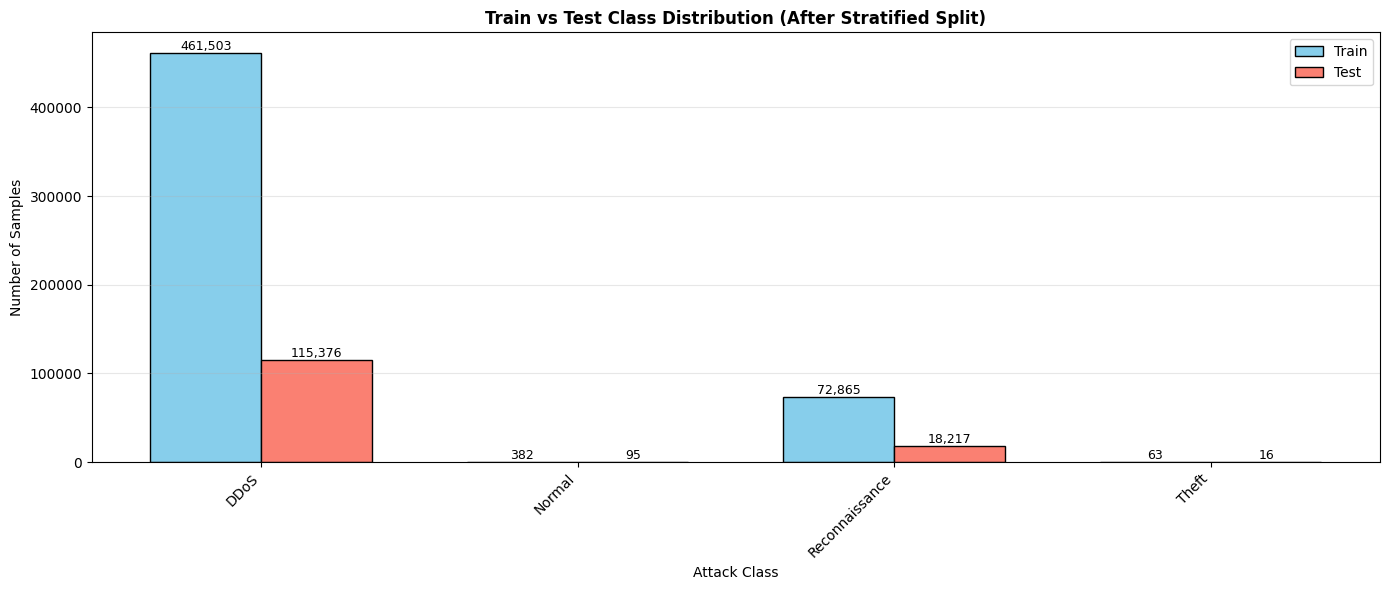

In [24]:
# =============================================================================
# CELL 9A: CLASS DISTRIBUTION – TRAIN vs TEST
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

train_counts = np.bincount(y_train)
test_counts  = np.bincount(y_test)

x = np.arange(len(train_counts))
width = 0.35

plt.figure(figsize=(14,6))
plt.bar(x - width/2, train_counts, width, label='Train', color='skyblue', edgecolor='black')
plt.bar(x + width/2, test_counts,  width, label='Test',  color='salmon',  edgecolor='black')

plt.title("Train vs Test Class Distribution (After Stratified Split)", fontweight='bold')
plt.xlabel("Attack Class")
plt.ylabel("Number of Samples")
plt.xticks(x, target_encoder.classes_, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add count labels
for i in range(len(x)):
    plt.text(i - width/2, train_counts[i], f"{train_counts[i]:,}", ha='center', va='bottom', fontsize=9)
    plt.text(i + width/2, test_counts[i],  f"{test_counts[i]:,}",  ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


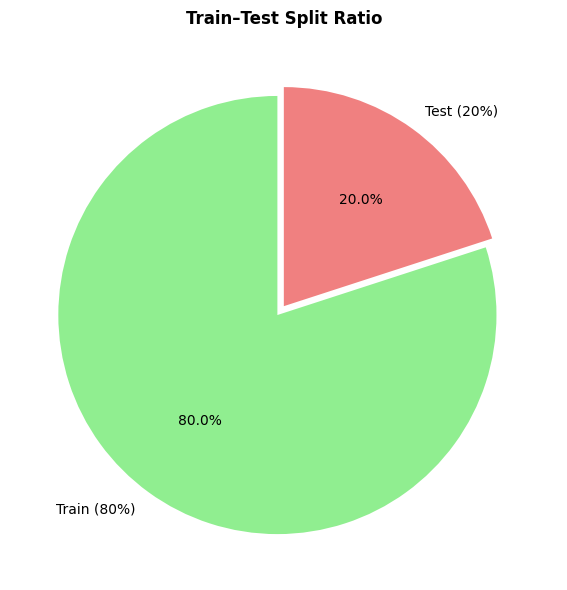

In [25]:
# =============================================================================
# CELL 9B: TRAIN–TEST SPLIT RATIO
# =============================================================================

plt.figure(figsize=(6,6))
plt.pie(
    [len(y_train), len(y_test)],
    labels=['Train (80%)', 'Test (20%)'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightgreen', 'lightcoral'],
    explode=(0.05, 0)
)

plt.title("Train–Test Split Ratio", fontweight='bold')
plt.tight_layout()
plt.show()


In [14]:
# =============================================================================
# CELL 10: CLASS WEIGHTS
# =============================================================================

class_counts = np.bincount(y_train)
class_weights = 1.0 / (class_counts + 1e-6)
class_weights = class_weights * (len(class_counts) / class_weights.sum())
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:", class_weights)


Class weights: tensor([4.6833e-04, 5.6581e-01, 2.9663e-03, 3.4308e+00])


In [15]:
# =============================================================================
# QKV-HAN MODEL
# =============================================================================

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, input_dim, d_model, heads):
        super().__init__()
        self.qkv = nn.Linear(input_dim, d_model * 3)
        self.heads = heads
        self.d_model = d_model
        self.head_dim = d_model // heads
        self.out = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, _ = x.size()
        qkv = self.qkv(x).view(B, T, self.heads, 3*self.head_dim)
        qkv = qkv.permute(0,2,1,3)
        q,k,v = qkv.chunk(3, dim=-1)
        scores = (q @ k.transpose(-1,-2)) / math.sqrt(self.head_dim)
        attn = torch.softmax(scores, dim=-1)
        out = (attn @ v).permute(0,2,1,3).contiguous()
        out = out.view(B,T,self.d_model)
        return self.out(out)

class QKV_HAN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.gru1 = nn.GRU(input_dim, 64, bidirectional=True, batch_first=True)
        self.attn1 = MultiHeadSelfAttention(128, 128, 4)
        self.gru2 = nn.GRU(128, 64, bidirectional=True, batch_first=True)
        self.attn2 = MultiHeadSelfAttention(128, 128, 4)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        h,_ = self.gru1(x)
        h = self.attn1(h)
        h,_ = self.gru2(h)
        h = self.attn2(h)
        h = h.mean(dim=1)
        return self.fc(h)

model = QKV_HAN(X_final.shape[2], num_classes).to(device)


In [18]:
# =============================================================================
# CELL 15: SAFE TRAINING LOOP (NO DATALOADER, NO NUMPY)
# =============================================================================

batch_size = 128
epochs = 10

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

N = X_train_t.size(0)

print("🚀 Training started (NumPy-free, crash-proof)...")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    # 🔹 Pure PyTorch shuffling (NO NumPy)
    indices = torch.randperm(N)

    for start in range(0, N, batch_size):
        end = start + batch_size
        batch_idx = indices[start:end]

        xb = X_train_t[batch_idx].to(device)
        yb = y_train_t[batch_idx].to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # 🔹 Aggressive memory cleanup
        del xb, yb, outputs, loss
        torch.cuda.empty_cache()

    avg_loss = epoch_loss / (N // batch_size + 1)

    # 🔹 Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for start in range(0, X_test_t.size(0), batch_size):
            xb = X_test_t[start:start+batch_size].to(device)
            yb = y_test_t[start:start+batch_size].to(device)

            preds = model(xb).argmax(1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

            del xb, yb, preds
            torch.cuda.empty_cache()

    acc = correct / total
    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Val Acc: {acc*100:.2f}%")


🚀 Training started (NumPy-free, crash-proof)...
Epoch 01 | Loss: 0.0480 | Val Acc: 99.97%
Epoch 02 | Loss: 0.0315 | Val Acc: 99.99%
Epoch 03 | Loss: 0.0165 | Val Acc: 99.93%
Epoch 04 | Loss: 0.0196 | Val Acc: 99.99%
Epoch 05 | Loss: 0.0144 | Val Acc: 99.97%
Epoch 06 | Loss: 0.0518 | Val Acc: 99.99%
Epoch 07 | Loss: 0.0373 | Val Acc: 99.98%
Epoch 08 | Loss: 0.0222 | Val Acc: 99.98%
Epoch 09 | Loss: 0.0267 | Val Acc: 100.00%
Epoch 10 | Loss: 0.0349 | Val Acc: 99.99%


In [19]:
# =============================================================================
# CELL 17: FINAL EVALUATION (NUMPY-SAFE)
# =============================================================================

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for start in range(0, X_test_t.size(0), batch_size):
        xb = X_test_t[start:start+batch_size].to(device)
        outputs = model(xb).argmax(1).cpu().tolist()
        y_pred.extend(outputs)
        y_true.extend(y_test_t[start:start+batch_size].tolist())

acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

print("\nFINAL PERFORMANCE")
print(f"Accuracy : {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall   : {rec*100:.2f}%")
print(f"F1-score : {f1*100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=target_encoder.classes_,
    zero_division=0
))



FINAL PERFORMANCE
Accuracy : 99.99%
Precision: 99.98%
Recall   : 99.99%
F1-score : 99.98%

Classification Report:
                precision    recall  f1-score   support

          DDoS       1.00      1.00      1.00    115376
        Normal       0.93      1.00      0.96        95
Reconnaissance       1.00      1.00      1.00     18217
         Theft       0.75      0.38      0.50        16

      accuracy                           1.00    133704
     macro avg       0.92      0.84      0.87    133704
  weighted avg       1.00      1.00      1.00    133704



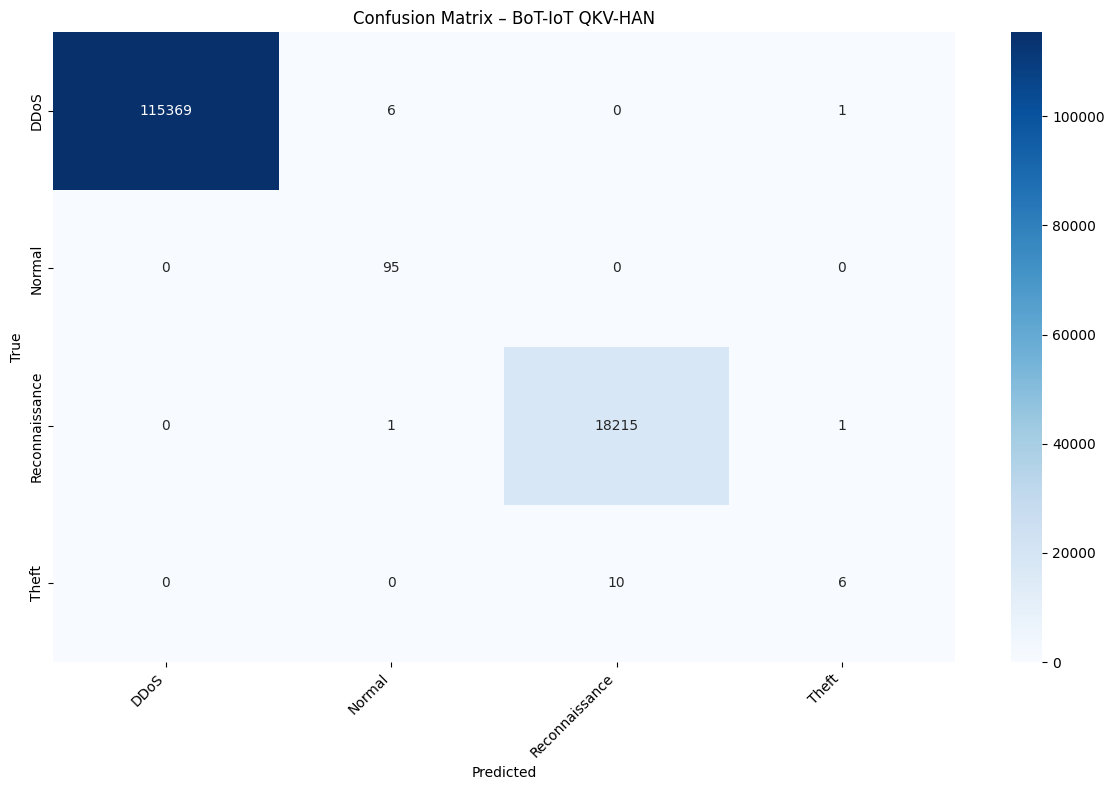

<Figure size 640x480 with 0 Axes>

✅ confusion matrix saved at:
C:\Users\chari\Downloads\Major Project\BoT_IoT Visual\confusion_matrix.png


In [33]:
# =============================================================================
# CELL 18: CONFUSION MATRIX (SAVE TO PATH)
# =============================================================================

import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Save directory
save_path = r"C:\Users\chari\Downloads\Major Project\BoT_IoT Visual"
os.makedirs(save_path, exist_ok=True)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

plt.title("Confusion Matrix – BoT-IoT QKV-HAN", fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# ✅ SAVE FIRST
file_name = "confusion_matrix.png"
plt.savefig(os.path.join(save_path, file_name), dpi=300)

# ✅ THEN SHOW
plt.show()

print("✅ Confusion matrix saved successfully at:")
print(os.path.join(save_path, file_name))


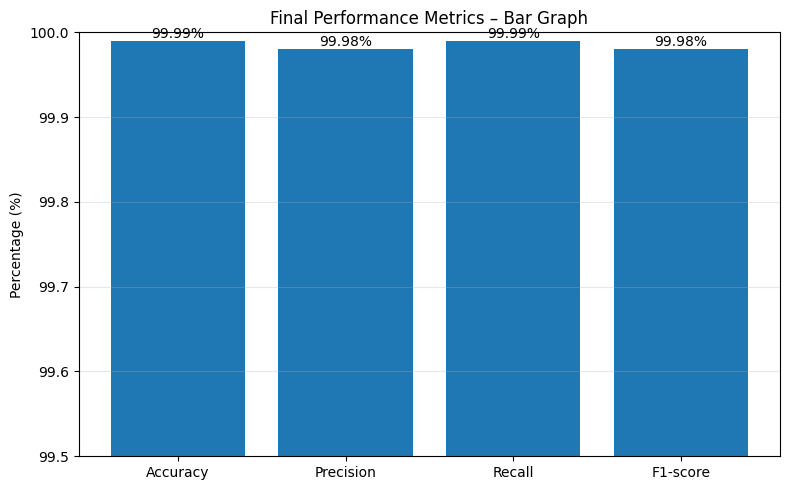

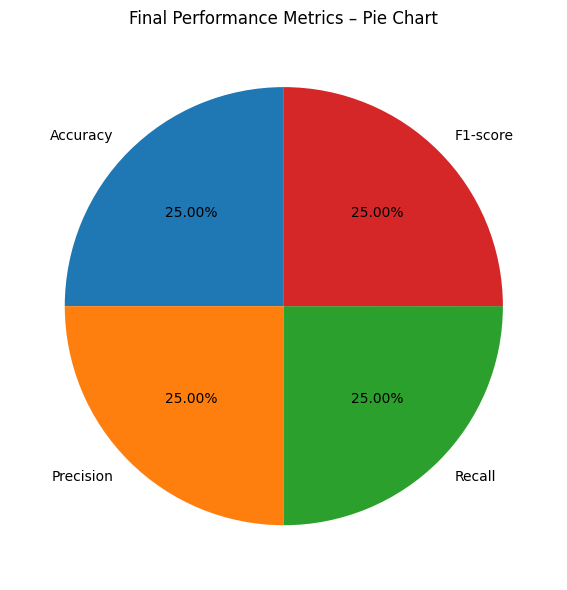

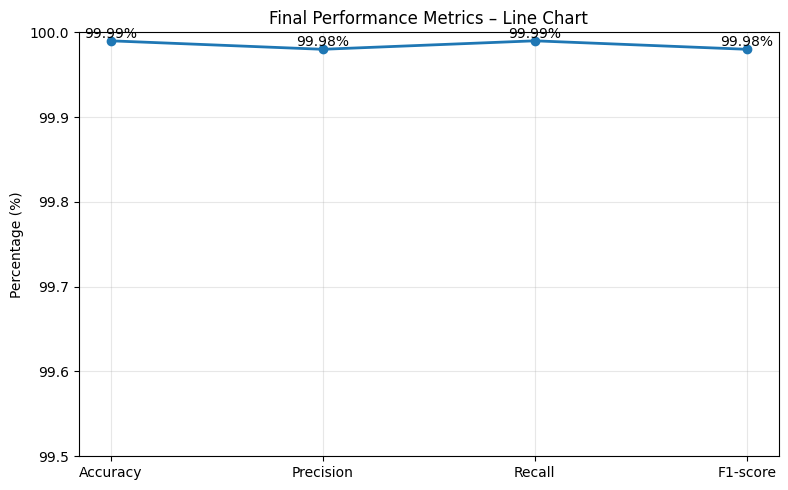

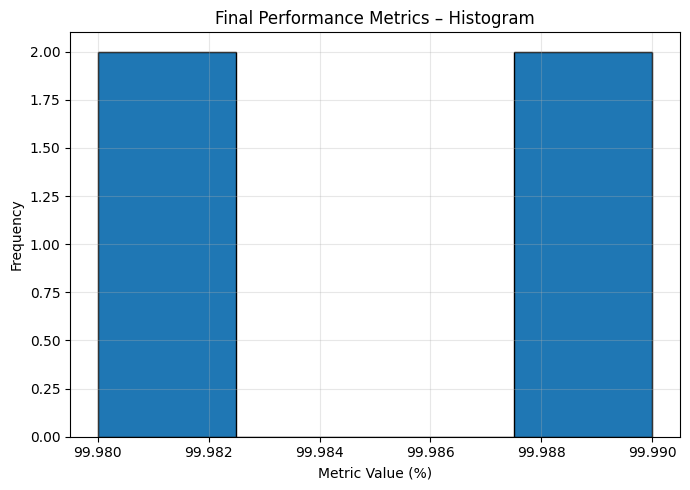

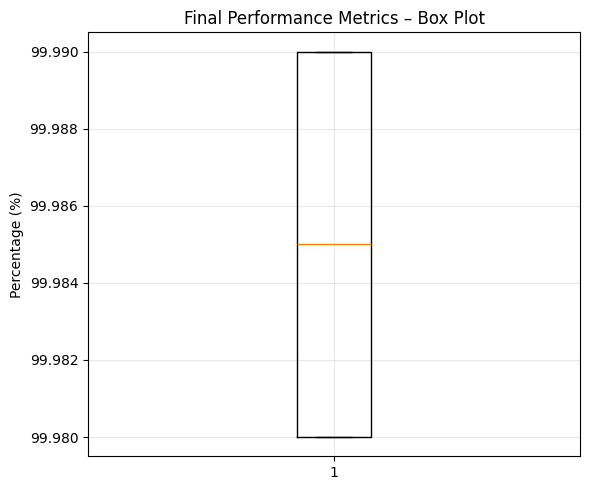

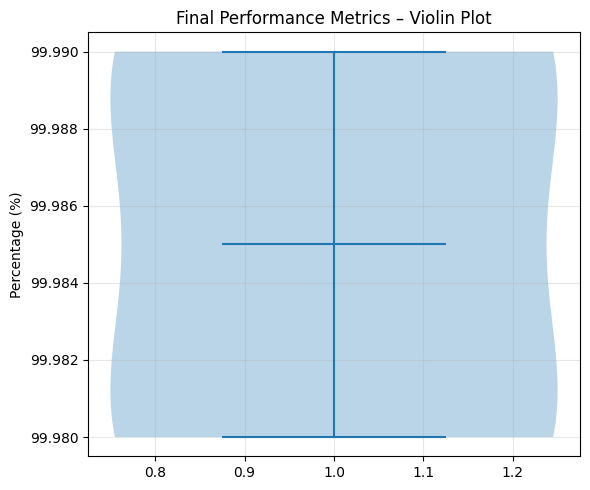

✅ All performance plots saved successfully at:
C:\Users\chari\Downloads\Major Project\BoT_IoT Visual


In [27]:
# =============================================================================
# FINAL PERFORMANCE VISUALIZATIONS (SAVE TO DISK)
# =============================================================================

import os
import matplotlib.pyplot as plt

# Create output directory if not exists
save_path = r"C:\Users\chari\Downloads\Major Project\BoT_IoT Visual"
os.makedirs(save_path, exist_ok=True)

# Performance values
metrics = {
    "Accuracy": 99.99,
    "Precision": 99.98,
    "Recall": 99.99,
    "F1-score": 99.98
}

names = list(metrics.keys())
values = list(metrics.values())

# -------------------------------------------------
# 1️⃣ BAR GRAPH
# -------------------------------------------------
plt.figure(figsize=(8,5))
bars = plt.bar(names, values)
plt.ylim(99.5, 100)
plt.title("Final Performance Metrics – Bar Graph")
plt.ylabel("Percentage (%)")
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height():.2f}%", ha='center', va='bottom')

plt.tight_layout()
plt.savefig(os.path.join(save_path, "bar_graph.png"), dpi=300)
plt.show()

# -------------------------------------------------
# 2️⃣ PIE CHART
# -------------------------------------------------
plt.figure(figsize=(6,6))
plt.pie(values, labels=names, autopct='%1.2f%%', startangle=90)
plt.title("Final Performance Metrics – Pie Chart")
plt.tight_layout()
plt.savefig(os.path.join(save_path, "pie_chart.png"), dpi=300)
plt.show()

# -------------------------------------------------
# 3️⃣ LINE CHART
# -------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(names, values, marker='o', linewidth=2)
plt.ylim(99.5, 100)
plt.title("Final Performance Metrics – Line Chart")
plt.ylabel("Percentage (%)")
plt.grid(alpha=0.3)

for i, v in enumerate(values):
    plt.text(i, v, f"{v:.2f}%", ha='center', va='bottom')

plt.tight_layout()
plt.savefig(os.path.join(save_path, "line_chart.png"), dpi=300)
plt.show()

# -------------------------------------------------
# 4️⃣ HISTOGRAM
# -------------------------------------------------
plt.figure(figsize=(7,5))
plt.hist(values, bins=4, edgecolor='black')
plt.title("Final Performance Metrics – Histogram")
plt.xlabel("Metric Value (%)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_path, "histogram.png"), dpi=300)
plt.show()

# -------------------------------------------------
# 5️⃣ BOX PLOT
# -------------------------------------------------
plt.figure(figsize=(6,5))
plt.boxplot(values, vert=True)
plt.title("Final Performance Metrics – Box Plot")
plt.ylabel("Percentage (%)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_path, "box_plot.png"), dpi=300)
plt.show()

# -------------------------------------------------
# 6️⃣ VIOLIN PLOT
# -------------------------------------------------
plt.figure(figsize=(6,5))
plt.violinplot(values, showmeans=True)
plt.title("Final Performance Metrics – Violin Plot")
plt.ylabel("Percentage (%)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_path, "violin_plot.png"), dpi=300)
plt.show()

print("✅ All performance plots saved successfully at:")
print(save_path)


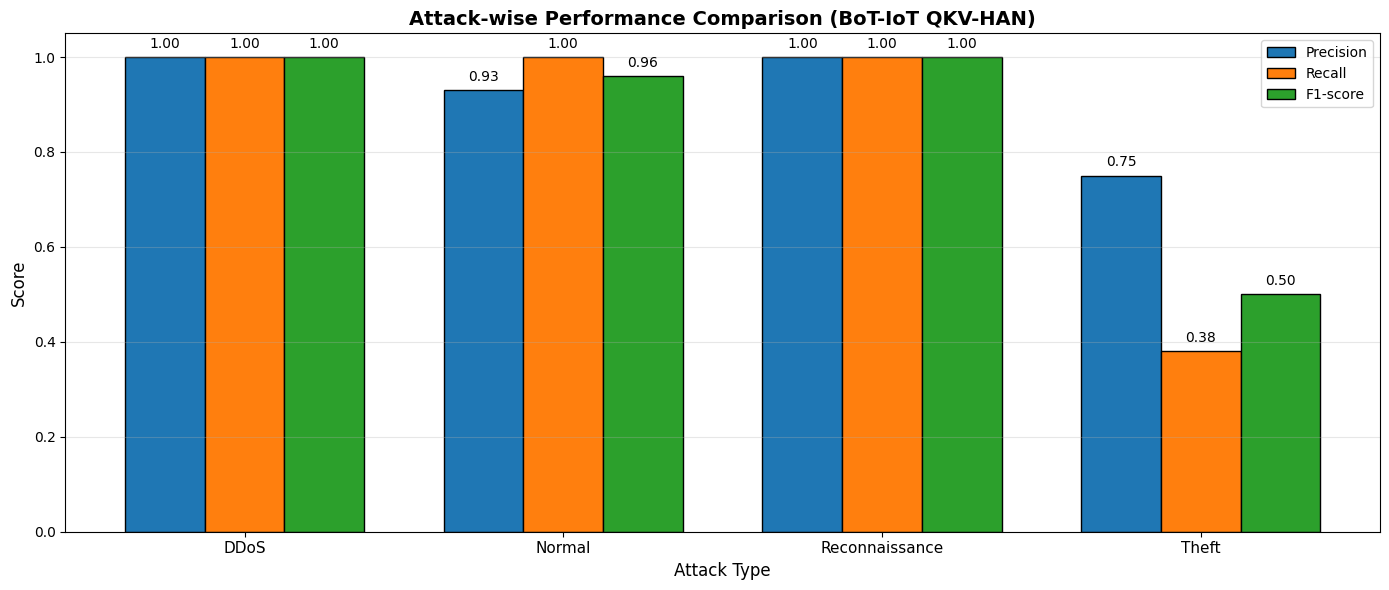

✅ Attack-wise performance bar graph saved at:
C:\Users\chari\Downloads\Major Project\BoT_IoT Visual\attack_wise_performance_bar_graph.png


In [29]:
# =============================================================================
# ATTACK-WISE PERFORMANCE METRICS VISUALIZATION (SAVE TO DISK)
# =============================================================================

import os
import matplotlib.pyplot as plt
import numpy as np

# Save directory
save_path = r"C:\Users\chari\Downloads\Major Project\BoT_IoT Visual"
os.makedirs(save_path, exist_ok=True)

# Attack classes
attack_types = ['DDoS', 'Normal', 'Reconnaissance', 'Theft']

# Metrics from classification report
precision = [1.00, 0.93, 1.00, 0.75]
recall    = [1.00, 1.00, 1.00, 0.38]
f1_score  = [1.00, 0.96, 1.00, 0.50]

x = np.arange(len(attack_types))
width = 0.25

plt.figure(figsize=(14,6))

plt.bar(x - width, precision, width, label='Precision', edgecolor='black')
plt.bar(x,         recall,    width, label='Recall',    edgecolor='black')
plt.bar(x + width, f1_score,  width, label='F1-score',  edgecolor='black')

plt.title(
    "Attack-wise Performance Comparison (BoT-IoT QKV-HAN)",
    fontsize=14,
    fontweight='bold'
)
plt.xlabel("Attack Type", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.05)
plt.xticks(x, attack_types, fontsize=11)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i in range(len(attack_types)):
    plt.text(x[i] - width, precision[i] + 0.02, f"{precision[i]:.2f}", ha='center', fontsize=10)
    plt.text(x[i],         recall[i]    + 0.02, f"{recall[i]:.2f}",    ha='center', fontsize=10)
    plt.text(x[i] + width, f1_score[i]  + 0.02, f"{f1_score[i]:.2f}",  ha='center', fontsize=10)

plt.tight_layout()

# Save figure
file_name = "attack_wise_performance_bar_graph.png"
plt.savefig(os.path.join(save_path, file_name), dpi=300)

plt.show()

print("✅ Attack-wise performance bar graph saved at:")
print(os.path.join(save_path, file_name))


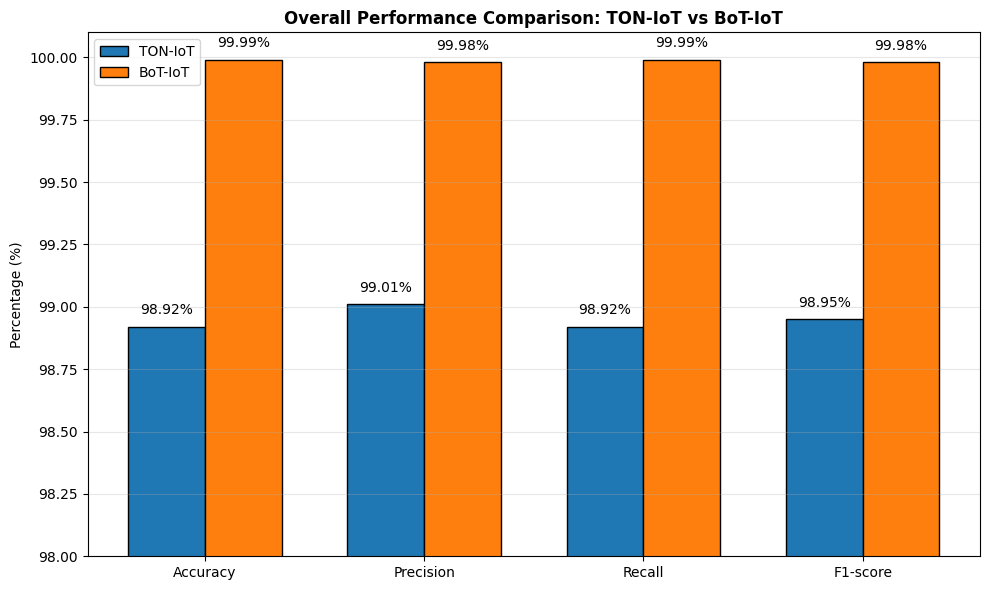

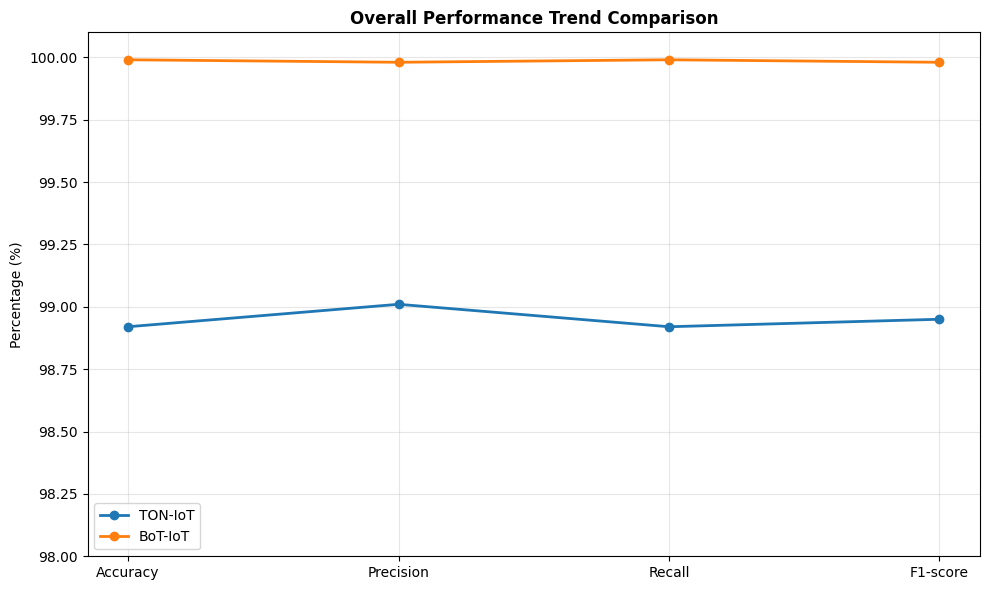

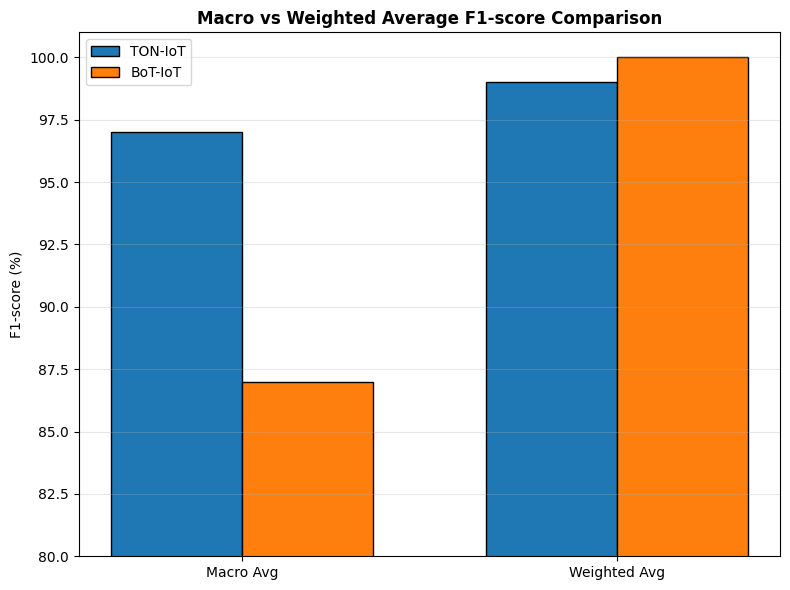

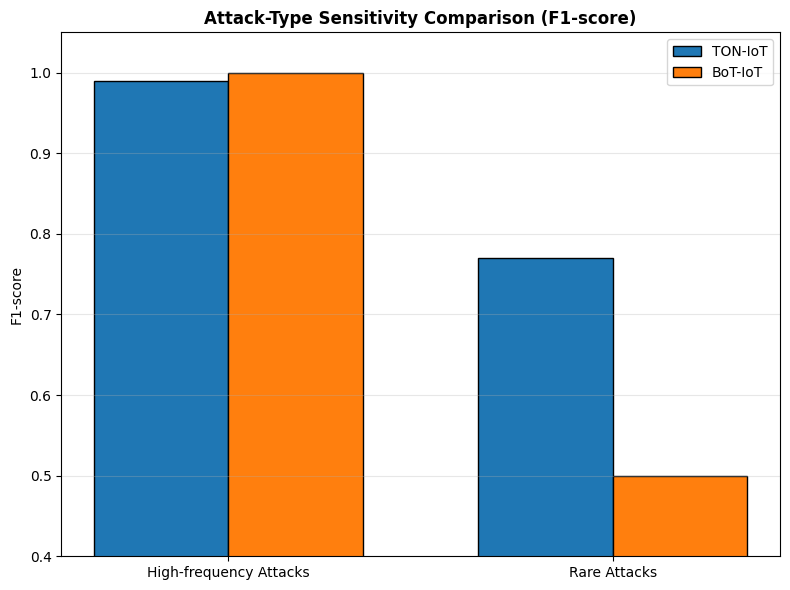

✅ All TON-IoT vs BoT-IoT comparison plots saved at:
C:\Users\chari\Downloads\Major Project\BoT_IoT Visual


In [35]:
# =============================================================================
# TON-IoT vs BoT-IoT PERFORMANCE COMPARISON (SAVE TO DISK)
# =============================================================================

import os
import matplotlib.pyplot as plt
import numpy as np

# Save directory
save_path = r"C:\Users\chari\Downloads\Major Project\BoT_IoT Visual"
os.makedirs(save_path, exist_ok=True)

# -------------------------------------------------
# 1️⃣ OVERALL METRICS COMPARISON (BAR GRAPH)
# -------------------------------------------------

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

ton_iot = [98.92, 99.01, 98.92, 98.95]
bot_iot = [99.99, 99.98, 99.99, 99.98]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, ton_iot, width, label="TON-IoT", edgecolor="black")
plt.bar(x + width/2, bot_iot, width, label="BoT-IoT", edgecolor="black")

plt.title("Overall Performance Comparison: TON-IoT vs BoT-IoT", fontweight="bold")
plt.ylabel("Percentage (%)")
plt.xticks(x, metrics)
plt.ylim(98, 100.1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

for i in range(len(metrics)):
    plt.text(x[i]-width/2, ton_iot[i]+0.05, f"{ton_iot[i]:.2f}%", ha="center")
    plt.text(x[i]+width/2, bot_iot[i]+0.05, f"{bot_iot[i]:.2f}%", ha="center")

plt.tight_layout()
plt.savefig(os.path.join(save_path, "overall_metrics_bar_comparison.png"), dpi=300)
plt.show()

# -------------------------------------------------
# 2️⃣ OVERALL METRICS COMPARISON (LINE CHART)
# -------------------------------------------------

plt.figure(figsize=(10,6))
plt.plot(metrics, ton_iot, marker="o", linewidth=2, label="TON-IoT")
plt.plot(metrics, bot_iot, marker="o", linewidth=2, label="BoT-IoT")

plt.title("Overall Performance Trend Comparison", fontweight="bold")
plt.ylabel("Percentage (%)")
plt.ylim(98, 100.1)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_path, "overall_metrics_line_comparison.png"), dpi=300)
plt.show()

# -------------------------------------------------
# 3️⃣ MACRO vs WEIGHTED AVERAGE COMPARISON
# -------------------------------------------------

averages = ["Macro Avg", "Weighted Avg"]

ton_macro_weighted = [97.0, 99.0]   # F1-score based
bot_macro_weighted = [87.0, 100.0]

x = np.arange(len(averages))

plt.figure(figsize=(8,6))
plt.bar(x - width/2, ton_macro_weighted, width, label="TON-IoT", edgecolor="black")
plt.bar(x + width/2, bot_macro_weighted, width, label="BoT-IoT", edgecolor="black")

plt.title("Macro vs Weighted Average F1-score Comparison", fontweight="bold")
plt.ylabel("F1-score (%)")
plt.xticks(x, averages)
plt.ylim(80, 101)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_path, "macro_weighted_comparison.png"), dpi=300)
plt.show()

# -------------------------------------------------
# 4️⃣ ATTACK-WISE F1-SCORE COMPARISON (SUMMARY VIEW)
# -------------------------------------------------

attack_sets = ["High-frequency Attacks", "Rare Attacks"]

ton_attack_f1 = [0.99, 0.77]   # Avg (mitm is weakest)
bot_attack_f1 = [1.00, 0.50]   # Theft is weakest

x = np.arange(len(attack_sets))

plt.figure(figsize=(8,6))
plt.bar(x - width/2, ton_attack_f1, width, label="TON-IoT", edgecolor="black")
plt.bar(x + width/2, bot_attack_f1, width, label="BoT-IoT", edgecolor="black")

plt.title("Attack-Type Sensitivity Comparison (F1-score)", fontweight="bold")
plt.ylabel("F1-score")
plt.xticks(x, attack_sets)
plt.ylim(0.4, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_path, "attack_type_f1_comparison.png"), dpi=300)
plt.show()

print("✅ All TON-IoT vs BoT-IoT comparison plots saved at:")
print(save_path)


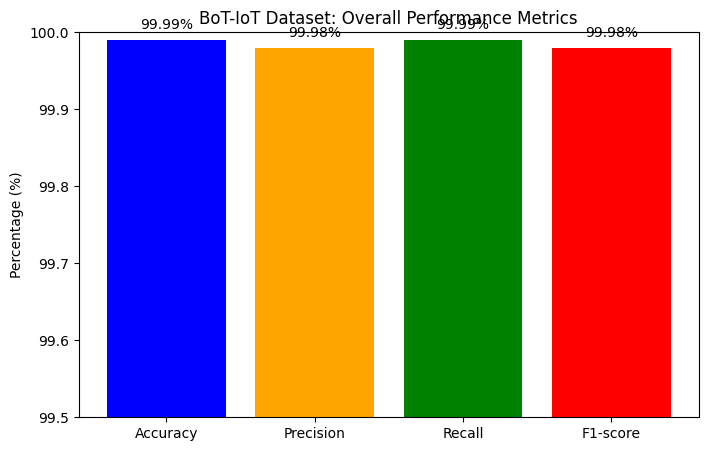

In [5]:
import matplotlib.pyplot as plt

# Overall performance metrics for BoT-IoT
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
#values = [99.99, 99.98, 99.99, 99.98]

# Different colors for each bar
colors = ['blue', 'orange', 'green', 'red']

# Create bar graph
plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, values, color=colors)

# Labels and title
plt.ylabel('Percentage (%)')
plt.title('BoT-IoT Dataset: Overall Performance Metrics')
plt.ylim(99.5, 100)

# Add value labels on top of each bar
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             value + 0.01,
             f'{value}%',
             ha='center',
             va='bottom',
             fontsize=10)

plt.show()


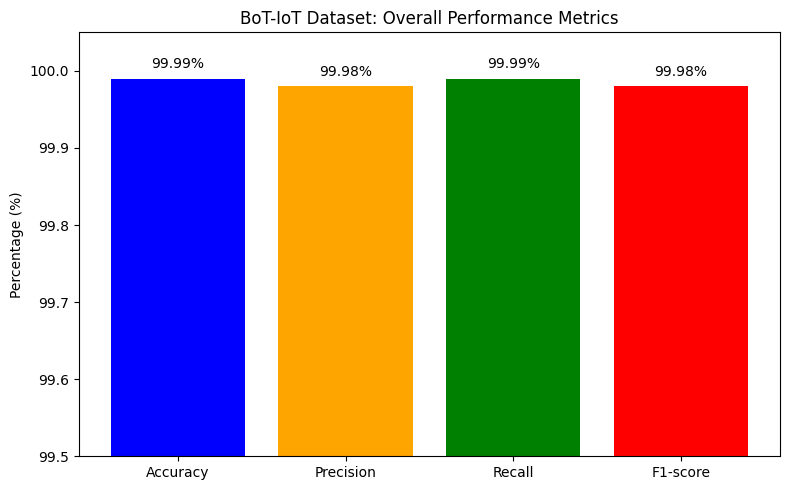

In [6]:
import matplotlib.pyplot as plt

# Overall performance metrics for BoT-IoT
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
values = [99.99, 99.98, 99.99, 99.98]

# Different colors for each bar
colors = ['blue', 'orange', 'green', 'red']

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, values, color=colors)

# Labels and title
plt.ylabel('Percentage (%)')
plt.title('BoT-IoT Dataset: Overall Performance Metrics')

# Increase y-axis limit to avoid overlap
plt.ylim(99.5, 100.05)

# Add value labels with proper spacing
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,          # vertical offset
        f'{value}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()


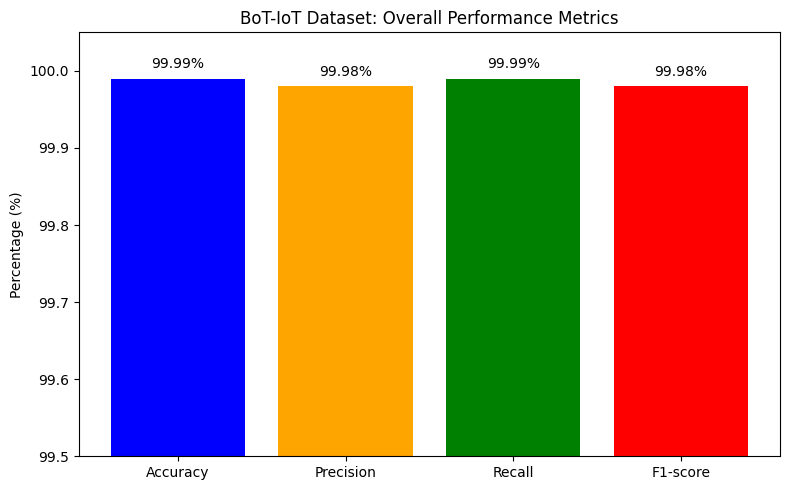

In [7]:
import matplotlib.pyplot as plt
import os

# Overall performance metrics for BoT-IoT
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
values = [99.99, 99.98, 99.99, 99.98]

# Different colors for each bar
colors = ['blue', 'orange', 'green', 'red']

# Create directory if it does not exist
save_path = r"C:\Users\chari\Downloads\Major Project\BoT_IoT Visual"
os.makedirs(save_path, exist_ok=True)

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, values, color=colors)

# Labels and title
plt.ylabel('Percentage (%)')
plt.title('BoT-IoT Dataset: Overall Performance Metrics')

# Increase y-axis limit to avoid overlap
plt.ylim(99.5, 100.05)

# Add value labels with proper spacing
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f'{value}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()

# Save the figure
plt.savefig(os.path.join(save_path, "BoT_IoT_Overall_Performance.png"), dpi=300)
plt.show()


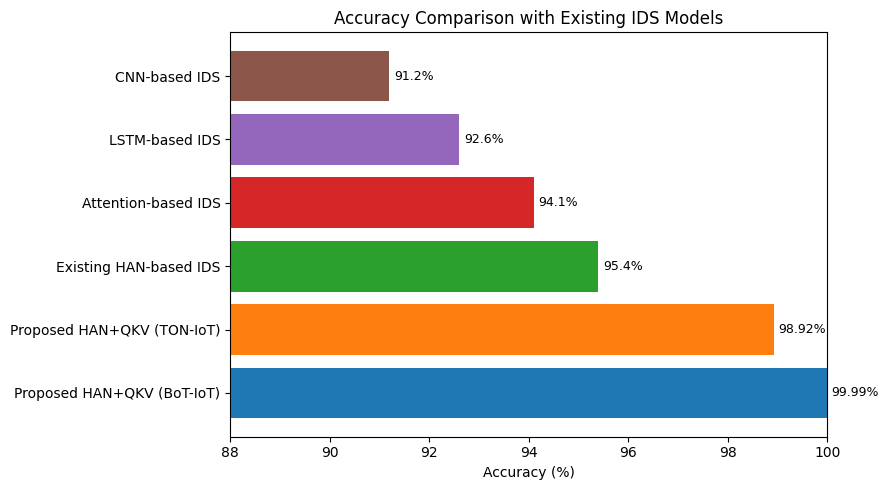

In [8]:
import matplotlib.pyplot as plt
import os

# Model names and accuracy values
models = [
    "Proposed HAN+QKV (BoT-IoT)",
    "Proposed HAN+QKV (TON-IoT)",
    "Existing HAN-based IDS",
    "Attention-based IDS",
    "LSTM-based IDS",
    "CNN-based IDS"
]

accuracy = [99.99, 98.92, 95.4, 94.1, 92.6, 91.2]

# Different colors for each bar
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

# Save path
save_path = r"C:\Users\chari\Downloads\Major Project\BoT_IoT Visual"
os.makedirs(save_path, exist_ok=True)

# Create figure
plt.figure(figsize=(9, 5))
bars = plt.barh(models, accuracy, color=colors)

# Labels and title
plt.xlabel("Accuracy (%)")
plt.title("Accuracy Comparison with Existing IDS Models")

# Set x-axis range
plt.xlim(88, 100)

# Annotate bars
for bar, value in zip(bars, accuracy):
    plt.text(value + 0.1, bar.get_y() + bar.get_height() / 2,
             f"{value}%", va='center', fontsize=9)

plt.tight_layout()

# Save the figure
plt.savefig(os.path.join(save_path, "Accuracy_Comparison_IDS_Models.png"), dpi=300)
plt.show()
